In [1]:
# Day 4 – Data Cleaning & Feature Engineering
# Member 2 — Agro-Analyst & Feature Engineer
# Goal: Verify clean data, run features.py, inspect output

In [21]:
import numpy as np

In [24]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import joblib


# This must be BEFORE any imports from src
sys.path.insert(0, r"C:\Users\Hp Envy\Desktop\m5-project-weather-pipeline\src")

# Force Python to use YOUR config not the installed one
import importlib
import config
importlib.reload(config)
from config import DB_PATH, STAGES, COTTON_BASE_TEMP, MODELS_DIR, FIGURES_DIR

con = duckdb.connect(DB_PATH)
sns.set_theme(style="whitegrid")
print("Connected to DuckDB ✓")
print(f"DB_PATH: {DB_PATH}")

Connected to DuckDB ✓
DB_PATH: C:\Users\Hp Envy\Desktop\m5-project-weather-pipeline\data\cotton_project.duckdb


In [25]:
print("=" * 55)
print("STEP 1 — Quality Checks")
print("=" * 55)

# Check features_with_risk exists
existing = [t[0] for t in con.execute("SHOW TABLES").fetchall()]
if "features_with_risk" not in existing:
    raise Exception("features_with_risk NOT FOUND — pull Member 2's work first!")

# Null check
nulls = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(*) FILTER (WHERE yield_tonnes IS NULL) AS null_yield,
        COUNT(*) FILTER (WHERE growing_GDD IS NULL)  AS null_gdd,
        COUNT(*) FILTER (WHERE overall_risk_score IS NULL) AS null_risk
    FROM features_with_risk
""").df()

print(f"  Total rows:  {nulls['total_rows'][0]}")
print(f"  Null yield:  {nulls['null_yield'][0]}")
print(f"  Null GDD:    {nulls['null_gdd'][0]}")
print(f"  Null risk:   {nulls['null_risk'][0]}")
print(f"  {'ALL CHECKS PASSED ✓' if nulls['null_yield'][0] == 0 else 'NULLS FOUND ✗'}")

# Train/test split
split = con.execute("""
    SELECT
        COUNT(*) FILTER (WHERE year <= 2021) AS train_rows,
        COUNT(*) FILTER (WHERE year >  2021) AS test_rows,
        COUNT(DISTINCT region)               AS districts
    FROM features_with_risk
""").df()
print(f"\n  Train rows (≤2021): {split['train_rows'][0]}")
print(f"  Test  rows (>2021): {split['test_rows'][0]}")
print(f"  Districts:          {split['districts'][0]}")

STEP 1 — Quality Checks
  Total rows:  375
  Null yield:  0
  Null GDD:    0
  Null risk:   0
  ALL CHECKS PASSED ✓

  Train rows (≤2021): 330
  Test  rows (>2021): 45
  Districts:          15


In [26]:
print("=" * 55)
print("STEP 2 — Preparing Data for Modeling")
print("=" * 55)

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, classification_report
)
from sklearn.utils import resample

df = con.execute("SELECT * FROM features_with_risk").df()

le = LabelEncoder()
df["region_encoded"] = le.fit_transform(df["region"])
joblib.dump(le, os.path.join(MODELS_DIR, "label_encoder.pkl"))

exclude = [
    "region","weather_station","year","yield_tonnes",
    "yield_deviation",
    "planting_risk_score","planting_risk_label",
    "growing_risk_score","growing_risk_label",
    "boll_risk_score","boll_risk_label",
    "harvest_risk_score","harvest_risk_label",
    "overall_risk_score","overall_risk_label"
]
feature_cols = [c for c in df.columns if c not in exclude]

train = df[df["year"] <= 2021]
test  = df[df["year"] >  2021]

print(f"  Feature columns: {len(feature_cols)}")
print(f"  Train rows:      {len(train)}")
print(f"  Test rows:       {len(test)}")

STEP 2 — Preparing Data for Modeling
  Feature columns: 53
  Train rows:      330
  Test rows:       45


In [27]:
print("=" * 55)
print("STEP 3 — Training Risk Classifiers")
print("=" * 55)

risk_models = {}
risk_preds  = pd.DataFrame(index=df.index)

for stage in ["planting","growing","boll","harvest"]:
    label_col = f"{stage}_risk_label"
    clf = RandomForestClassifier(
        n_estimators=200, max_depth=6,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    )
    clf.fit(train[feature_cols], train[label_col])
    y_pred = clf.predict(test[feature_cols])

    print(f"\n  {stage.upper()} RISK:")
    print(classification_report(test[label_col], y_pred, zero_division=0))

    joblib.dump(clf, os.path.join(MODELS_DIR, f"risk_{stage}.pkl"))
    print(f"  Saved → models/risk_{stage}.pkl ✓")

    probs = clf.predict_proba(df[feature_cols])[:, 1] * 100
    risk_preds[f"{stage}_risk_pred"] = probs
    risk_models[stage] = clf

STEP 3 — Training Risk Classifiers

  PLANTING RISK:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00         6

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

  Saved → models/risk_planting.pkl ✓

  GROWING RISK:
              precision    recall  f1-score   support

           0       1.00      0.47      0.64        45
           1       0.00      0.00      0.00         0

    accuracy                           0.47        45
   macro avg       0.50      0.23      0.32        45
weighted avg       1.00      0.47      0.64        45

  Saved → models/risk_growing.pkl ✓

  BOLL RISK:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        21
           1       1.00      0.75      0.86        24

    accuracy             

In [28]:
print("=" * 55)
print("STEP 4 — Training Yield Models")
print("=" * 55)

df_full       = pd.concat([
    df.reset_index(drop=True),
    risk_preds.reset_index(drop=True)
], axis=1)
risk_cols     = list(risk_preds.columns)
all_feat_cols = feature_cols + risk_cols

train_f = df_full[df_full["year"] <= 2021]
test_f  = df_full[df_full["year"] >  2021]
X_train = train_f[all_feat_cols]
X_test  = test_f[all_feat_cols]
y_train = train_f["yield_tonnes"]
y_test  = test_f["yield_tonnes"]

model_results = {}
for name, model in [
    ("Random Forest", RandomForestRegressor(
        n_estimators=300, max_depth=8, random_state=42)),
    ("XGBoost", XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, random_state=42, verbosity=0))
]:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae   = mean_absolute_error(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    mape  = np.mean(np.abs((y_test - preds) / (y_test + 1e-5))) * 100

    print(f"\n  {name}:")
    print(f"    MAE:  {mae:.2f} tonnes")
    print(f"    RMSE: {rmse:.2f} tonnes")
    print(f"    R²:   {r2:.3f}")
    print(f"    MAPE: {mape:.1f}%")
    model_results[name] = (model, rmse, preds)

best_name  = min(model_results, key=lambda k: model_results[k][1])
best_model = model_results[best_name][0]
best_preds = model_results[best_name][2]
print(f"\n  Best model: {best_name} ✓")

joblib.dump(best_model,    os.path.join(MODELS_DIR, "yield_model.pkl"))
joblib.dump(all_feat_cols, os.path.join(MODELS_DIR, "feature_columns.pkl"))
print(f"  Saved → models/yield_model.pkl ✓")

STEP 4 — Training Yield Models

  Random Forest:
    MAE:  6.27 tonnes
    RMSE: 7.05 tonnes
    R²:   -3.834
    MAPE: 20.6%

  XGBoost:
    MAE:  4.73 tonnes
    RMSE: 6.43 tonnes
    R²:   -3.030
    MAPE: 15.8%

  Best model: XGBoost ✓
  Saved → models/yield_model.pkl ✓


STEP 5 — Model Evaluation


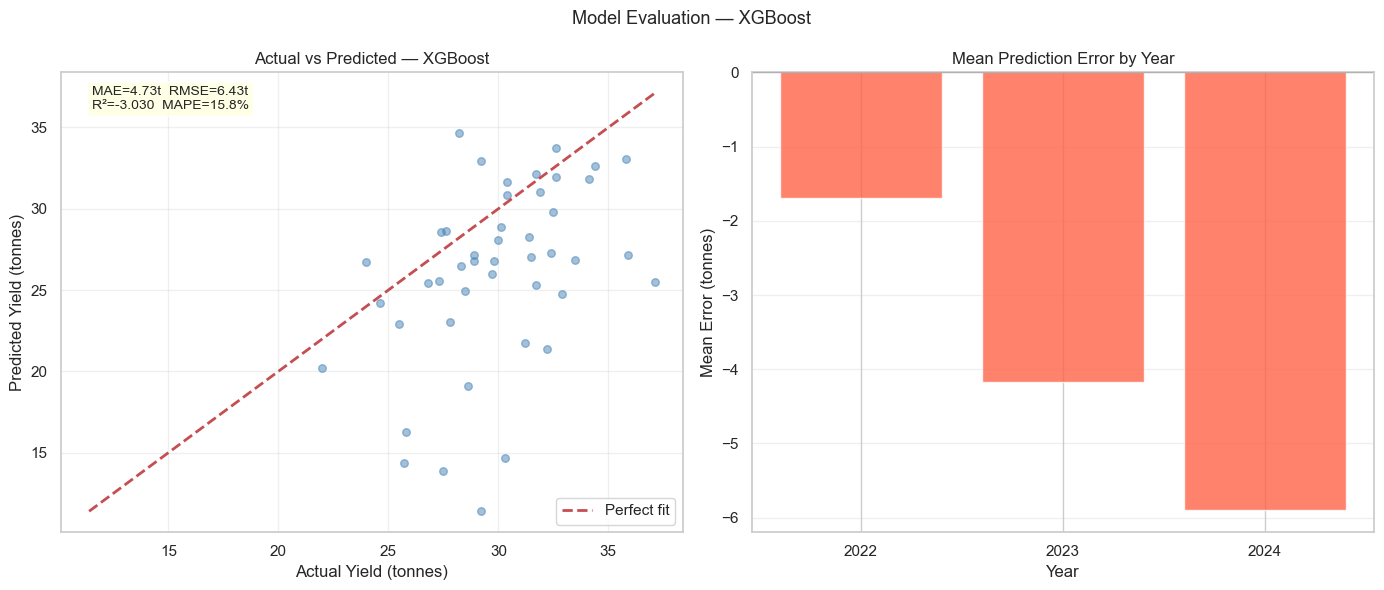

Saved: model_01_evaluation.png


In [29]:
print("=" * 55)
print("STEP 5 — Model Evaluation")
print("=" * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: actual vs predicted
ax = axes[0]
ax.scatter(y_test, best_preds, alpha=0.5,
           color="steelblue", s=30)
mn = min(y_test.min(), best_preds.min())
mx = max(y_test.max(), best_preds.max())
ax.plot([mn,mx],[mn,mx], "r--", linewidth=2, label="Perfect fit")
mae  = mean_absolute_error(y_test, best_preds)
rmse = np.sqrt(mean_squared_error(y_test, best_preds))
r2   = r2_score(y_test, best_preds)
mape = np.mean(np.abs((y_test - best_preds)/(y_test+1e-5)))*100
ax.text(0.05, 0.92,
        f"MAE={mae:.2f}t  RMSE={rmse:.2f}t\nR²={r2:.3f}  MAPE={mape:.1f}%",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
ax.set_xlabel("Actual Yield (tonnes)")
ax.set_ylabel("Predicted Yield (tonnes)")
ax.set_title(f"Actual vs Predicted — {best_name}")
ax.legend()
ax.grid(True, alpha=0.3)

# Error by year
ax  = axes[1]
test_f = test_f.copy()
test_f["predicted"] = best_preds
test_f["error"]     = test_f["predicted"] - test_f["yield_tonnes"]
yearly_err = test_f.groupby("year")["error"].mean()
colors_e   = ["seagreen" if e >= 0 else "tomato" for e in yearly_err.values]
ax.bar(yearly_err.index.astype(str), yearly_err.values,
       color=colors_e, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean Prediction Error by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Error (tonnes)")
ax.grid(True, axis="y", alpha=0.3)

plt.suptitle(f"Model Evaluation — {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_01_evaluation.png"), dpi=150)
plt.show()
print("Saved: model_01_evaluation.png")

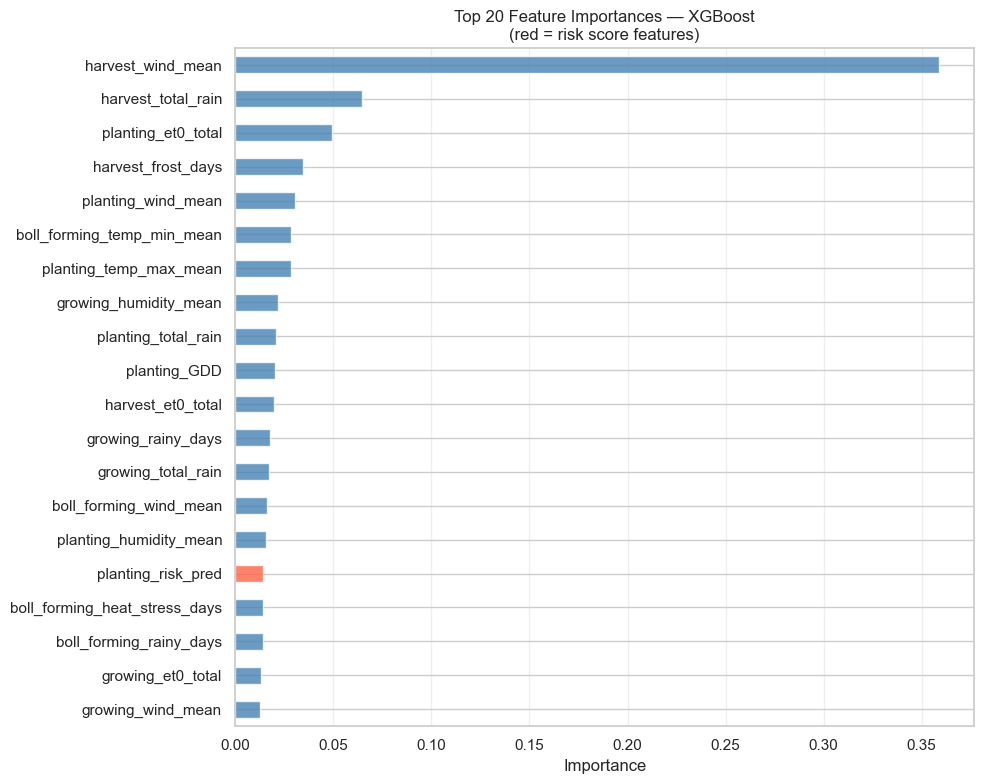

Saved: model_02_feature_importance.png


In [30]:
importances = best_model.feature_importances_
feat_imp    = pd.Series(importances, index=all_feat_cols)\
    .sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors_f = ["tomato" if "risk_pred" in f else "steelblue"
            for f in feat_imp.index]
feat_imp.plot(kind="barh", ax=ax, color=colors_f, alpha=0.8)
ax.set_title(f"Top 20 Feature Importances — {best_name}\n"
             f"(red = risk score features)")
ax.set_xlabel("Importance")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_02_feature_importance.png"), dpi=150)
plt.show()
print("Saved: model_02_feature_importance.png")

In [32]:
con.close()

In [34]:
print("=" * 55)
print("STEP 6 — Running Predictions (2025 & 2026)")
print("with Bootstrap Confidence Intervals")
print("=" * 55)

import subprocess
result = subprocess.run(
    ["python", "../src/models.py"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("ERRORS:")
    print(result.stderr)

STEP 6 — Running Predictions (2025 & 2026)
with Bootstrap Confidence Intervals
[2026-04-25 19:18:16] 
[2026-04-25 19:18:16] MEMBER 3 â€” QUALITY CHECKS
[2026-04-25 19:18:16] =======================================================
[2026-04-25 19:18:16] 
Check 1 â€” Null values in features_with_risk:
[2026-04-25 19:18:16]   Total rows:   375
[2026-04-25 19:18:16]   Null yield:   0
[2026-04-25 19:18:16]   Null GDD:     0
[2026-04-25 19:18:16]   Null risk:    0
[2026-04-25 19:18:16]   PASSED âœ“
[2026-04-25 19:18:16] 
Check 2 â€” Train/test split:
[2026-04-25 19:18:16]   Train rows (â‰¤2021): 330
[2026-04-25 19:18:16]   Test  rows (>2021):  45
[2026-04-25 19:18:16]   Districts:              15
[2026-04-25 19:18:16]   PASSED âœ“
[2026-04-25 19:18:16] 
Check 3 â€” Risk label distribution:
[2026-04-25 19:18:16]   Label 0: 234 rows, avg yield = 23.39 tonnes
[2026-04-25 19:18:16]   Label 1: 141 rows, avg yield = 11.18 tonnes
[2026-04-25 19:18:16]   PASSED âœ“
[2026-04-25 19:18:16] 
Check 4 â€” 

In [36]:
print("=" * 55)
print("STEP 7 — Predictions Stored in DuckDB")
print("=" * 55)

# reopen connection
con = duckdb.connect(DB_PATH)

for pred_year in [2025, 2026]:
    print(f"\n  {pred_year} PREDICTIONS:")
    
    preds = con.execute(f"""
        SELECT region, predicted_yield, historical_avg,
               pct_vs_avg, overall_risk
        FROM predictions
        WHERE year = {pred_year}
        ORDER BY predicted_yield DESC
    """).df()
    
    display(preds)

    total_pred = preds["predicted_yield"].sum()
    total_hist = preds["historical_avg"].sum()
    pct        = (total_pred - total_hist) / total_hist * 100

    print(f"  Total predicted: {total_pred:.0f}t")
    print(f"  Historical avg:  {total_hist:.0f}t")
    print(f"  Overall change:  {pct:+.1f}%")

STEP 7 — Predictions Stored in DuckDB

  2025 PREDICTIONS:


,region,predicted_yield,historical_avg,pct_vs_avg,overall_risk
0,Barda district,27.7,23.3,18.8,48.5
1,Tartar district,24.1,22.7,6.1,35.3
2,Yevlakh district,23.3,23.6,-1.5,35.3
3,Aghjabadi district,22.6,20.3,11.5,48.5
4,Beylagan district,21.8,20.7,5.3,48.5
5,Saatli district,21.4,20.5,4.5,48.5
6,Aghdam district,19.8,18.3,8.1,35.2
7,Imishli district,18.6,18.0,3.8,48.5
8,Goranboy district,18.3,18.6,-1.5,35.2
9,Bilasuvar district,16.8,19.0,-11.4,22.7


  Total predicted: 287t
  Historical avg:  282t
  Overall change:  +1.9%

  2026 PREDICTIONS:


,region,predicted_yield,historical_avg,pct_vs_avg,overall_risk
0,Yevlakh district,23.9,23.6,1.3,33.2
1,Tartar district,21.0,22.7,-7.6,33.2
2,Goranboy district,20.9,18.6,12.2,33.2
3,Aghdam district,20.9,18.3,14.1,33.2
4,Barda district,19.5,23.3,-16.2,47.8
5,Bilasuvar district,19.4,19.0,2.5,24.6
6,Salyan district,18.1,18.7,-3.4,24.6
7,Aghjabadi district,17.6,20.3,-13.3,47.8
8,Neftchala district,16.8,16.0,5.1,24.6
9,Beylagan district,15.6,20.7,-24.7,47.8


  Total predicted: 262t
  Historical avg:  282t
  Overall change:  -7.2%


In [37]:
print("=" * 55)
print("DAY 8 COMPLETE — FINAL TABLE INVENTORY")
print("=" * 55)

all_tables = con.execute("SHOW TABLES").fetchall()
owners = {
    "raw_cotton":          "Member 1",
    "raw_weather":         "Member 1",
    "clean_cotton":        "Member 1",
    "clean_weather":       "Member 1",
    "features":            "Member 2",
    "features_with_risk":  "Member 2",
    "predictions":         "Member 3",
}
for t in all_tables:
    name  = t[0]
    count = con.execute(f"SELECT COUNT(*) FROM {name}").fetchone()[0]
    cols  = len(con.execute(f"SELECT * FROM {name} LIMIT 1").description)
    owner = owners.get(name, "Unknown")
    print(f"  {name:<25} {count:>6} rows  {cols:>3} cols  ← {owner}")

print("=" * 55)
print(f"\nModels saved to models/:")
for f in os.listdir(MODELS_DIR):
    print(f"  ✓ {f}")

con.close()
print("\nMember 3 complete. Push to GitHub so Member 4 can pull.")

DAY 8 COMPLETE — FINAL TABLE INVENTORY
  clean_cotton                 375 rows    4 cols  ← Member 1
  clean_weather              45655 rows   13 cols  ← Member 1
  features                     375 rows   56 cols  ← Member 2
  features_with_risk           375 rows   67 cols  ← Member 2
  predictions                   30 rows   10 cols  ← Member 3
  raw_cotton                   725 rows    3 cols  ← Member 1
  raw_weather                45660 rows   13 cols  ← Member 1

Models saved to models/:
  ✓ feature_columns.pkl
  ✓ label_encoder.pkl
  ✓ risk_boll.pkl
  ✓ risk_growing.pkl
  ✓ risk_harvest.pkl
  ✓ risk_planting.pkl
  ✓ yield_model.pkl

Member 3 complete. Push to GitHub so Member 4 can pull.
